In [3]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import pandas as pd
import re
import rasterio
from rasterio.transform import from_origin
from pyproj import Transformer
import re
import scipy as sp
import pyreadr
import sys
sys.path.append(os.path.abspath('../src/'))
from utils import *
from scipy import stats
import argparse
import copy
import glob
import argparse
import cProfile
import csv
from functools import partial
import itertools
import math
import matplotlib.pyplot as plt
import multiprocessing as mp
import numpy as np
import os
import rasterio
from scipy import stats
from scipy.optimize import minimize
# from scipy.special import binom
from skimage import graph
import sys
import time
from tqdm import tqdm
import numpy.ma as ma
import warnings
import numpy as np
import psutil
import gc

warnings.filterwarnings("ignore")

import logging
logging.getLogger("distributed").setLevel(logging.ERROR)


Bad key "text.kerning_factor" on line 4 in
/opt/anaconda3/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test_patch.mplstyle.
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.1.3/matplotlibrc.template
or from the matplotlib source distribution


### Forward Greedy with Base

In [18]:
import pandas as pd
from scipy.spatial import distance
import numpy as np

# Load the data
file_path = './only_trail/500m/trail_candidate_traps_spacing500.csv'
traps_df = pd.read_csv(file_path)

# Extract coordinates as numpy array
coords = traps_df[['x', 'y']].to_numpy()

# Calculate the pairwise distance matrix
dist_matrix = distance.cdist(coords, coords, 'euclidean')

# Find all pairs (i, j) where distance is within 500m and i != j
pairs = np.where((dist_matrix <= 500) & (dist_matrix > 0))

# Collect unique pairs once (i < j to avoid duplicates)
unique_pairs = [
    (int(traps_df.iloc[i]['Trap_index']), int(traps_df.iloc[j]['Trap_index']))
    for i, j in zip(pairs[0], pairs[1]) if i < j
]

# Example: print the results
for pair in unique_pairs:
    print(pair)


(1, 29)
(1, 778)
(1, 779)
(1, 780)
(1, 809)
(2, 35)
(2, 36)
(2, 37)
(2, 783)
(2, 785)
(2, 808)
(3, 19)
(3, 788)
(3, 789)
(3, 790)
(3, 792)
(3, 1310)
(4, 22)
(4, 510)
(4, 511)
(4, 955)
(4, 966)
(5, 551)
(5, 552)
(5, 569)
(5, 572)
(5, 1363)
(5, 1364)
(6, 7)
(6, 350)
(6, 353)
(6, 401)
(6, 404)
(6, 1354)
(7, 8)
(7, 350)
(7, 351)
(7, 353)
(7, 354)
(8, 351)
(8, 352)
(8, 354)
(8, 712)
(9, 27)
(9, 522)
(9, 523)
(9, 524)
(9, 960)
(10, 11)
(10, 494)
(11, 422)
(12, 568)
(12, 570)
(12, 571)
(12, 573)
(12, 575)
(12, 576)
(12, 1028)
(12, 1029)
(12, 1364)
(12, 1365)
(13, 14)
(13, 421)
(13, 422)
(13, 427)
(13, 429)
(14, 421)
(14, 502)
(14, 503)
(15, 16)
(15, 498)
(15, 500)
(15, 501)
(15, 502)
(15, 503)
(15, 574)
(15, 579)
(15, 1366)
(16, 17)
(16, 502)
(16, 503)
(16, 504)
(17, 502)
(17, 503)
(17, 504)
(18, 625)
(18, 972)
(18, 1308)
(19, 611)
(19, 789)
(19, 790)
(19, 792)
(19, 1310)
(20, 21)
(20, 611)
(20, 612)
(20, 789)
(20, 792)
(20, 793)
(20, 1309)
(21, 611)
(21, 612)
(21, 789)
(21, 792)
(21, 793)
(2

In [19]:
print(len(unique_pairs), "pairs found within 500m distance.")

3392 pairs found within 500m distance.


In [20]:
import pandas as pd
from scipy.spatial import distance
import numpy as np

# Load the data
file_path = './only_trail/500m/trail_candidate_traps_spacing500.csv'
traps_df = pd.read_csv(file_path)

# Extract coordinates and indices
coords = traps_df[['x', 'y']].to_numpy()
trap_indices = traps_df['Trap_index'].to_numpy()

# Calculate pairwise distances
dist_matrix = distance.cdist(coords, coords, 'euclidean')

# Find all pairs (i, j) where distance is within 500m and i != j
pairs = np.where((dist_matrix <= 500) & (dist_matrix > 0))

# Collect unique pairs with i < j to avoid duplicates
unique_pairs = [(i, j) for i, j in zip(pairs[0], pairs[1]) if i < j]

# Track cameras to remove (we will remove the second camera in each pair)
to_remove_indices = set(j for i, j in unique_pairs)

# Alternative: if you want a deterministic removal to avoid removing multiple times,
# you can also do a greedy approach removing cameras, but the above is simplest

# Indices of cameras to keep
all_indices = set(range(len(traps_df)))
to_keep_indices = all_indices - to_remove_indices

# Filter original dataframe by kept indices
remaining_cameras = traps_df.iloc[list(to_keep_indices)]

print(f"Number of cameras before removal: {len(traps_df)}")
print(f"Number of cameras after removal: {len(remaining_cameras)}")

# Optional: Save remaining cameras to a new CSV
# remaining_cameras.to_csv('remaining_cameras.csv', index=False)


Number of cameras before removal: 1468
Number of cameras after removal: 286


In [11]:
ac_coords = pyreadr.read_r('./only_trail/mask_7-24-25.RDS')
ac_coords = ac_coords[None]
ac_coords_list = ac_coords[['x', 'y']].values.tolist()
ac_coords_list = np.array(ac_coords_list)
ac_coords_list

array([[ 508737.78721529, 5623510.46939679],
       [ 509237.78721529, 5623510.46939679],
       [ 509737.78721529, 5623510.46939679],
       ...,
       [ 491737.78721529, 5674010.46939679],
       [ 492237.78721529, 5674010.46939679],
       [ 492737.78721529, 5674010.46939679]])

In [13]:
# what x,y coords in scrpy/pgaff-testing/secr/Prior Deployment/deployed_cams_2024.csv are not in the scrpy/pgaff-testing/only_trail/500m/trail_candidate_traps_spacing500.csv?

deployed_cams = pd.read_csv('./secr/Prior Deployment/deployed_cams_2024.csv')
deployed_cams_coords = deployed_cams[['x', 'y']].values.tolist()
deployed_cams_coords = np.array(deployed_cams_coords)

candidate_cams = pd.read_csv('./only_trail/500m/trail_candidate_traps_spacing500.csv')
candidate_cams_coords = candidate_cams[['x', 'y']].values.tolist()
candidate_cams_coords = np.array(candidate_cams_coords)
# Find the coordinates in deployed_cams_coords that are not in candidate_cams_coords
missing_coords = []
for coord in deployed_cams_coords:
    if not any(np.array_equal(coord, candidate_coord) for candidate_coord in candidate_cams_coords):
        missing_coords.append(coord)
missing_coords = np.array(missing_coords)
print(len(missing_coords))


68


In [15]:
true_n = pd.read_csv('./only_trail/True_N_per_draw.csv')
# valid_ids = true_n['Parameter_draw'].tolist()                               # Change this if you want to filter with parameter draws in between some values of N or g0

params = pd.read_csv('./only_trail/param_values_for_each_draw150.csv')
params = params.rename(columns={'Unnamed: 0': 'index'})
params = params.sample(n=50).reset_index(drop=True)                          # Randomly select 5 draws
# params = params[params['index'].isin(valid_ids)].iloc[:5]
print(f"Using {params['index'].tolist()} parameter draws")

D, g0, sigma = params['D'].values, params['g0'].values, params['sigma'].values
draw = params['index'].tolist()
draw_to_trueN = dict(zip(true_n['Parameter_draw'], true_n['N']))

# Gather all potential activity center locations
ac_coords = pyreadr.read_r('./only_trail/mask_7-24-25.RDS')[None]
ac_coords_list = ac_coords[['x', 'y']].values

# Load full possible trap grid
full_trap_grid = pd.read_csv('./only_trail/500m/trail_candidate_traps_spacing500.csv').drop(columns=['Unnamed: 0'])
full_trap_grid = full_trap_grid.rename(columns={'X': 'x', 'Y': 'y'})

# Candidate traps after 50m accessibility filter
# excluded_ids = pd.read_csv('./500m_data/traps_to_remove_50m.csv')['TrapID']
# candidate_grid = full_trap_grid[~full_trap_grid['Trap_index'].isin(excluded_ids)].copy()
candidate_grid = full_trap_grid.copy()

# Load all 68 deployed traps
# deployed_df = pd.read_csv('./secr/Prior Deployment/deployed_cams_2024.csv')
# deployed_df = deployed_df[['x', 'y', 'Trap_index']]  # assuming correct format from file
deployed_df = full_trap_grid[full_trap_grid['Prior_cam']==1].copy()
deployed_df

candidate_exclusive = candidate_grid[~candidate_grid['Trap_index'].isin(deployed_df['Trap_index'])][['x', 'y', 'Trap_index']]

candidate_exclusive

Using [12, 144, 85, 113, 106, 130, 145, 101, 88, 87, 40, 98, 75, 108, 111, 64, 136, 133, 21, 102, 15, 90, 59, 143, 58, 120, 118, 36, 13, 107, 128, 29, 25, 104, 9, 124, 94, 71, 121, 5, 86, 97, 65, 139, 60, 1, 23, 91, 123, 20] parameter draws


,x,y,Trap_index
0,510670.337539,5.634173e+06,1
1,510589.866136,5.636167e+06,2
2,511461.885975,5.637240e+06,3
3,516098.336526,5.638313e+06,4
4,514871.344999,5.641862e+06,5
...,...,...,...
1395,502867.143885,5.653349e+06,1396
1396,502779.344158,5.652899e+06,1397
1397,514477.896293,5.639606e+06,1398
1398,514898.265452,5.639352e+06,1399


In [16]:
full_trap_grid

,Trap_index,Prior_cam,x,y
0,1,0,510670.337539,5.634173e+06
1,2,0,510589.866136,5.636167e+06
2,3,0,511461.885975,5.637240e+06
3,4,0,516098.336526,5.638313e+06
4,5,0,514871.344999,5.641862e+06
...,...,...,...,...
1463,1464,1,518167.891293,5.650812e+06
1464,1465,1,518510.603217,5.647950e+06
1465,1466,1,518138.971455,5.644505e+06
1466,1467,1,518435.484153,5.642722e+06


### File Manipulation

In [57]:
# Generate Files for SECR Analysis
trap_coords_list = np.load('secr/Backward Greedy/BG11/considered_trap_locs.npy')     # read in the traps considered in the algorithm run

with open('secr/Backward Greedy/BG11/activated_trap_hist.txt', 'r') as f:
    lines = f.readlines()

# Find the first line with exactly 60 elements
selected_line = None
for line in lines:
    # Clean and validate the line
    cleaned = line.strip().replace('[', '').replace(']', '').replace(' ', '')
    if cleaned:  # Skip empty lines
        elements = cleaned.split(',')
        if len(elements) == 20:
            selected_line = cleaned
            break  # Remove this line if you want the LAST occurrence instead

if not selected_line:
    raise ValueError("No line with 20 elements found in the file")

# convert string to list of integers
selected_traps = [int(x) for x in selected_line.split(',')]

# # Convert selected_traps to a numpy array and sort it
selected_traps = np.array(selected_traps)
selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub = trap_coords_list[selected_traps]
trap_coords_list_sub_df = pd.DataFrame(trap_coords_list_sub, columns=['x', 'y'])

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# get the x,y coords and index of the traps that were selected
trap_coords_list_sub_df = trap_coords_list_sub_df.merge(trap_coords, on=['x', 'y'], how='left')
trap_coords_list_sub_df.to_csv('secr/Backward Greedy/BG11/selected_traps-20.csv', index=False)
trap_coords_list_sub_df

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Backward Greedy/BG11/BG11-excluded_traps-20.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")

Selected 20 traps
Excluded 2417 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


In [91]:
# find the lat longs in scrpy/pgaff-testing/500m_data/SCM_deployed_cams_2024.csv that are not in 500m_trap_grid.csv
deployed_cams = pd.read_csv('deployed_cams_2024.csv')
deployed_cams = deployed_cams.rename(columns={'X': 'x', 'Y': 'y'})
# merge with trap_coords to find the traps that are not in the grid
deployed_cams = deployed_cams.merge(trap_coords, on=['x', 'y'], how='left')

In [92]:
deployed_cams

,Unnamed: 0,TrapID,x,y,Trap_index
0,1,2428,491737.787215,5.663510e+06,2428
1,2,1604,490737.787215,5.653510e+06,1604
2,3,1720,491737.787215,5.654510e+06,1720
3,4,1426,492237.787215,5.652010e+06,1426
4,5,2422,496237.787215,5.663010e+06,2422
...,...,...,...,...,...
63,64,1362,518237.787215,5.651010e+06,1362
64,65,1047,518737.787215,5.648010e+06,1047
65,66,680,518237.787215,5.644510e+06,680
66,67,474,518237.787215,5.642510e+06,474


In [94]:
deployed_cams.to_csv('secr/Prior Deployment/deployed_cams_2024.csv', index=False)

In [76]:
# Load the deployed cameras file and rename coordinate columns for consistency
deployed_cams = pd.read_csv('500m_data/SCM_deployed_cams_2024.csv')
deployed_cams = deployed_cams.rename(columns={'X': 'x', 'Y': 'y'})

# Load the full trap grid
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')

# Identify grid records (by x,y) that are not present in deployed cameras
not_in_deployed = trap_coords[
    ~trap_coords[['x', 'y']].apply(tuple, axis=1).isin(
        deployed_cams[['x', 'y']].apply(tuple, axis=1)
    )
]

not_in_deployed

not_in_deployed['Trap_index'].to_csv('not_in_2019_deployment.txt', index=False, header=False)


# with open('secr/2019 Deployment/deployed_cams_not_in_grid.txt', 'w') as f:
#     for item in deployed_cams_not_in_grid['TrapID']:
#         f.write("%s\n" % item)

In [93]:
not_in_deployed

,Unnamed: 0,Trap_index,x,y
0,1,1,509737.787215,5.633510e+06
1,2,2,510237.787215,5.633510e+06
2,3,3,510737.787215,5.633510e+06
3,4,4,511237.787215,5.633510e+06
4,5,5,509237.787215,5.634010e+06
...,...,...,...,...
2432,2433,2433,496737.787215,5.663510e+06
2433,2434,2434,489737.787215,5.664010e+06
2434,2435,2435,490237.787215,5.664010e+06
2435,2436,2436,490737.787215,5.664010e+06


In [73]:
deployed_cams

,Unnamed: 0,TrapID,x,y
0,1,2428,491737.787215,5.663510e+06
1,2,1604,490737.787215,5.653510e+06
2,3,1720,491737.787215,5.654510e+06
3,4,1426,492237.787215,5.652010e+06
4,5,2422,496237.787215,5.663010e+06
...,...,...,...,...
63,64,1362,518237.787215,5.651010e+06
64,65,1047,518737.787215,5.648010e+06
65,66,680,518237.787215,5.644510e+06
66,67,474,518237.787215,5.642510e+06


In [72]:
trap_coords

,Unnamed: 0,Trap_index,x,y
0,1,1,509737.787215,5.633510e+06
1,2,2,510237.787215,5.633510e+06
2,3,3,510737.787215,5.633510e+06
3,4,4,511237.787215,5.633510e+06
4,5,5,509237.787215,5.634010e+06
...,...,...,...,...
2432,2433,2433,496737.787215,5.663510e+06
2433,2434,2434,489737.787215,5.664010e+06
2434,2435,2435,490237.787215,5.664010e+06
2435,2436,2436,490737.787215,5.664010e+06


In [66]:
# Generate Files for SECR Analysis
trap_coords_list = pd.read_csv('./secr/Forward Greedy/FG7/considered_trap_locs.csv')
selected_traps = np.load('./secr/Forward Greedy/FG7/all_selected_traps.npy')
selected_traps = np.array(selected_traps)
selected_traps = selected_traps[:20]  # Limit to first 60 traps for testing
# selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub_df = trap_coords_list.iloc[selected_traps]
trap_coords_list_sub_df['Trap_index'] = trap_coords_list_sub_df.index + 1  # Adjust index to match SECR requirements
trap_coords_list_sub_df.to_csv('secr/Forward Greedy/FG7/selected_traps-20.csv', index=True)

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Forward Greedy/FG7/FG7-excluded_traps-20.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")


Selected 20 traps
Excluded 2417 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


In [89]:

# Generate Files for SECR Analysis
trap_coords_list = pd.read_csv('./secr/Forward Greedy/FG7/considered_trap_locs.csv')
selected_traps = np.load('./secr/Forward Greedy/FG7/all_selected_traps.npy')
selected_traps = np.array(selected_traps)
selected_traps = selected_traps[:68]  # Limit to first 60 traps for testing
selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub_df = trap_coords_list.iloc[selected_traps]
trap_coords_list_sub_df['Trap_index'] = trap_coords_list_sub_df.index + 1  # Adjust index to match SECR requirements
trap_coords_list_sub_df.to_csv('secr/Forward Greedy/FG7/selected_traps-68.csv', index=True)

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Forward Greedy/FG7/FG7-excluded_traps-68.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")


Selected 68 traps
Excluded 2369 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


In [85]:
trap_coords = pd.read_csv('./500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.drop(columns = ['Unnamed: 0'])
exclude_trap_coords = pd.read_csv('./500m_data/traps_to_remove_50m.csv')
trap_coords = trap_coords[~trap_coords['Trap_index'].isin(exclude_trap_coords['TrapID'])]
trap_coords_list = []
for i in range(trap_coords.shape[0]):
    trap_coords_list.append((trap_coords['x'].iloc[i], trap_coords['y'].iloc[i]))
trap_coords_list = np.array(trap_coords_list)
print(f"{trap_coords_list.shape} candidate trap locations")

trap_coords_list_df = pd.DataFrame(trap_coords_list, columns=['x', 'y'])
trap_coords_list_df.to_csv('./secr/Random/R3/considered_trap_locs.csv', index=False)

# randomly select 68 of the trap locations
selected_traps = np.random.choice(trap_coords_list.shape[0], size=68, replace=False)
trap_coords_list_sub_df = trap_coords_list_df.iloc[selected_traps]


# # Convert selected_traps to a numpy array and sort it
selected_traps = np.array(selected_traps)
selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub = trap_coords_list[selected_traps]
trap_coords_list_sub_df = pd.DataFrame(trap_coords_list_sub, columns=['x', 'y'])

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# get the x,y coords and index of the traps that were selected
trap_coords_list_sub_df = trap_coords_list_sub_df.merge(trap_coords, on=['x', 'y'], how='left')
trap_coords_list_sub_df.to_csv('secr/Random/R3/selected_traps.csv', index=False)
trap_coords_list_sub_df

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Random/R3/R3-excluded_traps.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")

(258, 2) candidate trap locations
Selected 68 traps
Excluded 2369 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


In [81]:
exclude_trap_coords

,TrapID,X,Y
0,1,509737.787215,5.633510e+06
1,2,510237.787215,5.633510e+06
2,3,510737.787215,5.633510e+06
3,4,511237.787215,5.633510e+06
4,5,509237.787215,5.634010e+06
...,...,...,...
2174,2433,496737.787215,5.663510e+06
2175,2434,489737.787215,5.664010e+06
2176,2435,490237.787215,5.664010e+06
2177,2436,490737.787215,5.664010e+06


### Costing Surfaces

In [98]:
traps = pd.read_csv('./500m_data/500m_trap_grid.csv')
deployed_cams = pd.read_csv('./secr/Prior Deployment/deployed_cams_2024.csv')

# Identify traps that are not in deployed_cams
not_in_deployed = traps[
    ~traps[['x', 'y']].apply(tuple, axis=1).isin(
        deployed_cams[['x', 'y']].apply(tuple, axis=1)
    )
]
not_in_deployed

not_in_deployed.to_csv('traps_to_remove_prior.csv')

In [99]:
not_in_deployed

,Unnamed: 0,Trap_index,x,y
0,1,1,509737.787215,5.633510e+06
1,2,2,510237.787215,5.633510e+06
2,3,3,510737.787215,5.633510e+06
3,4,4,511237.787215,5.633510e+06
4,5,5,509237.787215,5.634010e+06
...,...,...,...,...
2432,2433,2433,496737.787215,5.663510e+06
2433,2434,2434,489737.787215,5.664010e+06
2434,2435,2435,490237.787215,5.664010e+06
2435,2436,2436,490737.787215,5.664010e+06


In [29]:
costing_surface = pd.read_csv('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/500m_data/costing_surface.csv')

# get rows in costing_surface that do not have a NaN in rel_cost and have a Distance_to_trail_m less than 500
costing_surface_allowed = costing_surface[~(costing_surface['rel_cost'].isna()) & ~(costing_surface['Distance_to_trail_m'] > 500.00)]
costing_surface_allowed

,Unnamed: 0,Trap_index,Distance_to_trail_m,cost,rel_cost,X,Y
60,61,61,431.303809,916.542688,0.081414,508737.7872,5637010.469
61,62,62,361.697779,861.470553,0.076522,509237.7872,5637010.469
62,63,63,376.082558,818.130720,0.072672,509737.7872,5637010.469
63,64,64,370.426454,864.657365,0.076805,510237.7872,5637010.469
65,66,66,441.168219,877.416023,0.077938,511237.7872,5637010.469
...,...,...,...,...,...,...,...
2428,2429,2429,248.762323,3529.317834,0.313499,494737.7872,5663510.469
2429,2430,2430,116.778259,3468.382344,0.308086,495237.7872,5663510.469
2430,2431,2431,25.001649,3496.168778,0.310554,495737.7872,5663510.469
2431,2432,2432,252.564797,3635.222101,0.322906,496237.7872,5663510.469


In [ ]:
# from selected_traps.csv in FG11, return a csv that has just the x,y coordinates of those that are not in deployed_cams_2024.csv
selected_traps = pd.read_csv('secr/Forward Greedy/FG11/selected_traps-20.csv')


In [22]:
# Step 1: Combine all x,y coordinates from AC_locations into one DataFrame
ac_files = glob.glob('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/only_trail/AC_locations/*.csv')
ac_coords = []

for file in ac_files:
    df = pd.read_csv(file)
    if 'x' in df.columns and 'y' in df.columns:
        ac_coords.append(df[['x', 'y']])

# Concatenate all the coordinate DataFrames
ac_coords_df = pd.concat(ac_coords, ignore_index=True)

# Save to a single CSV file
# combined_path = '7-21 data/AC_locations/combined_ac_coords.csv'
ac_coords_df.to_csv('combined_ac_coords.csv', index=False)
print(f"Combined coordinates saved")

Combined coordinates saved


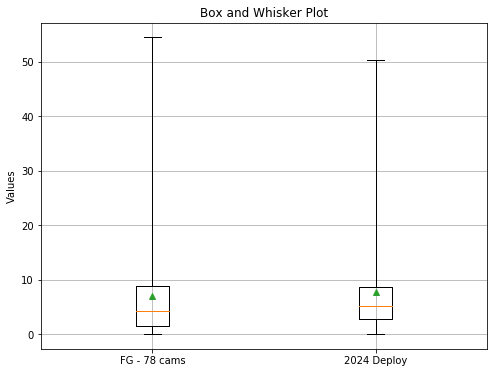

In [107]:
import matplotlib.pyplot as plt

# Summary statistics
labels = ['FG - 78 cams', '2024 Deploy']
min_vals = [0.049, 0.026]
q1 = [1.54, 2.72]
median = [4.22, 5.08]
q3 = [8.77, 8.58]
max_vals = [54.47, 50.25]
means = [6.97, 7.76]

# Prepare boxplot data for matplotlib's bxp() function
box_data = []
for i in range(len(labels)):
    box_data.append({
        'label': labels[i],
        'whislo': min_vals[i],     # Lower whisker (min)
        'q1': q1[i],               # First quartile (Q1)
        'med': median[i],          # Median (Q2)
        'q3': q3[i],               # Third quartile (Q3)
        'whishi': max_vals[i],     # Upper whisker (max)
        'mean': means[i],          # Mean (optional)
        'fliers': []               # No outliers available
    })

# Create the box and whisker plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.bxp(box_data, showmeans=True)
ax.set_ylabel('Values')
ax.set_title('Box and Whisker Plot')
ax.grid(True)
plt.show()


In [ ]:
# add the data from all the files in AC_locations into a singular csv file.


In [33]:
costing_surface_disallowed = costing_surface[(costing_surface['rel_cost'].isna()) | (costing_surface['Distance_to_trail_m'] > 500.00)]
# get the trap_index, x, and y of the disallowed rows
costing_surface_disallowed = costing_surface_disallowed[['Trap_index', 'X', 'Y']].reset_index(drop=True)
# save the disallowed rows to a csv file
costing_surface_disallowed.to_csv('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/500m_data/traps_to_remove_cost_500m.csv', index=False)

In [38]:
costing_surface = pd.read_csv('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/500m_data/costing_surface.csv')

# get rows in costing_surface that do not have a NaN in rel_cost and have a Distance_to_trail_m less than 50
costing_surface_allowed = costing_surface[~(costing_surface['Rel_cost'].isna())]
costing_surface_allowed


costing_surface_disallowed = costing_surface[(costing_surface['Rel_cost'].isna())]
# get the trap_index, x, and y of the disallowed rows
costing_surface_disallowed = costing_surface_disallowed[['TrapID', 'X', 'Y']].reset_index(drop=True)
# save the disallowed rows to a csv file
costing_surface_disallowed.to_csv('/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/500m_data/traps_to_remove_50m.csv', index=False)

In [31]:
costing_surface

,Unnamed: 0,Trap_index,Distance_to_trail_m,cost,rel_cost,X,Y
0,1,1,3842.015535,NaN,NaN,509737.7872,5633510.469
1,2,2,3855.952509,NaN,NaN,510237.7872,5633510.469
2,3,3,3874.371793,NaN,NaN,510737.7872,5633510.469
3,4,4,3822.221227,NaN,NaN,511237.7872,5633510.469
4,5,5,3355.109326,NaN,NaN,509237.7872,5634010.469
...,...,...,...,...,...,...,...
2432,2433,2433,171.146726,3789.301023,0.336592,496737.7872,5663510.469
2433,2434,2434,4130.440150,NaN,NaN,489737.7872,5664010.469
2434,2435,2435,3668.201922,NaN,NaN,490237.7872,5664010.469
2435,2436,2436,3217.277553,NaN,NaN,490737.7872,5664010.469


In [52]:
import numpy as np

def average_diff_and_abs_diff_for_iteration(file_path, iteration_num):
    """
    Returns both the average error (Diff, signed)
    and the average absolute error (|Diff|) for the given iteration.
    """
    diffs = []
    with open(file_path, 'r') as f:
        found_iter = False
        target_iter_line = f"Iteration {iteration_num}:"
        for line in f:
            if line.strip().startswith(target_iter_line):
                found_iter = True
                continue
            if found_iter:
                if line.strip().startswith('Iteration'):
                    # Reached next iteration, stop reading further
                    break
                if 'Diff=' in line:
                    try:
                        diff_value = float(line.split('Diff=')[1].strip())
                        diffs.append(diff_value)
                    except ValueError:
                        continue
    if not diffs:
        print(f"No 'Diff' values found for iteration {iteration_num}.")
        return None, None
    average_error = np.mean(diffs)
    average_abs_error = np.mean(np.abs(diffs))
    print(f"Average Error for iteration {iteration_num}: {average_error}")
    print(f"Average Absolute Error for iteration {iteration_num}: {average_abs_error}")
    return average_error, average_abs_error

# Example usage:
file_path = '/Users/hannahmurray/Documents/GitHub/Sensor-Opt/scrpy/pgaff-testing/secr/Backward Greedy/BG8/n_tracker.txt'
iteration_num = 238  # Change to desired iteration
average_diff_and_abs_diff_for_iteration(file_path, iteration_num)


Average Error for iteration 238: -32.418700740400105
Average Absolute Error for iteration 238: 32.418700740400105


(-32.418700740400105, 32.418700740400105)

In [21]:
# In each capture history file, determine what individuals and how many were observed.
def get_individuals(capture_history_file):
    """
    Return the unique number of individuals in the 'individual' column
    """
    with open(capture_history_file, 'r') as file:
        reader = csv.DictReader(file)
        individuals = set()
        for row in reader:
            individual = row['individual']
            individuals.add(individual)
    return individuals

def get_recaptures(capture_history_file):
    """
    Return the number of individuals that have been captured more than once.
    """
    with open(capture_history_file, 'r') as file:
        reader = csv.DictReader(file)
        individual_counts = {}
        for row in reader:
            individual = row['individual']
            if individual in individual_counts:
                individual_counts[individual] += 1
            else:
                individual_counts[individual] = 1
        # Count individuals with more than one capture
        recaptures = sum(1 for count in individual_counts.values() if count > 1)
    return recaptures


def get_spatial_recaptures(capture_history_file):
    with open(capture_history_file, 'r') as file:
        reader = csv.DictReader(file)        
        individual_locations = {}
        for row in reader:
            indv = row['individual']
            loc = (row['trap_id'])
            if indv not in individual_locations:
                individual_locations[indv] = set()
            individual_locations[indv].add(loc)
        
        # Count individuals with >1 unique location
        return sum(1 for locs in individual_locations.values() if len(locs) > 1)


# run for all the files in pgaff-testing/500m_data/capture_history/
def process_capture_history_files(directory):
    """
    Process all capture history files in the given directory.
    """
    results = []
    for filename in tqdm(os.listdir(directory)):
        if filename.endswith('.csv'):
            file_path = os.path.join(directory, filename)
            individuals = get_individuals(file_path)
            recaptures = get_recaptures(file_path)
            spatial_recaptures = get_spatial_recaptures(file_path)
            results.append({
                'file': filename,
                'individuals': len(individuals),
                'recaptures': recaptures,
                'spatial_recaptures': spatial_recaptures           
                })
    # return results as a dataframe with the number at the end of the cpature history file then the unique individuals detected in the other column
    results_df = pd.DataFrame(results)
    results_df['capture_history'] = results_df['file'].apply(lambda x: re.search(r'(\d+)', x).group(1) if re.search(r'(\d+)', x) else None)
    # convert both columsn to integers
    results_df['capture_history'] = results_df['capture_history'].astype(int)
    results_df = results_df[['capture_history', 'individuals', 'recaptures', 'spatial_recaptures']]
    results_df['observations'] = results_df['individuals'].astype(int)
    results_df['recaptures'] = results_df['recaptures'].astype(int)
    results_df['spatial_recaptures'] = results_df['spatial_recaptures'].astype(int)
    results_df = results_df.sort_values(by='capture_history')
    results_df.reset_index(drop=True, inplace=True)
    # Save the results to a CSV file
    output_file = os.path.join(directory, 'individuals_observed.csv')
    results_df.to_csv(output_file, index=False)
    return results_df

process_capture_history_files('only_trail/500m/ch')  # Adjust the path as needed

100%|██████████| 150/150 [00:04<00:00, 36.98it/s]


,capture_history,individuals,recaptures,spatial_recaptures,observations
0,1,36,29,29,36
1,2,19,16,16,19
2,3,59,58,58,59
3,4,64,60,60,64
4,5,16,13,13,16
...,...,...,...,...,...
145,146,39,32,32,39
146,147,70,67,67,70
147,148,17,16,16,17
148,149,41,33,33,41


In [19]:
# Generate Files for SECR Analysis
trap_coords_list = pd.read_csv('./secr/Forward Greedy/FG3/considered_trap_locs.csv')
selected_traps = np.load('./secr/Forward Greedy/FG3/all_selected_traps.npy')
selected_traps = np.array(selected_traps)
selected_traps = selected_traps[:20]  # Limit to first 60 traps for testing
selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub_df = trap_coords_list.iloc[selected_traps]
trap_coords_list_sub_df['Trap_index'] = trap_coords_list_sub_df.index + 1  # Adjust index to match SECR requirements
trap_coords_list_sub_df.to_csv('secr/Forward Greedy/FG3/selected_traps_20.csv', index=True)

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Forward Greedy/FG3/FG3-excluded_traps_20.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")


Selected 20 traps
Excluded 2417 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437


In [88]:
# Generate Files for SECR Analysis
trap_coords_list = np.load('secr/Backward Greedy/BG8/considered_trap_locs.npy')     # read in the traps considered in the algorithm run

with open('secr/Backward Greedy/BG11/activated_trap_hist.txt', 'r') as f:
    lines = f.readlines()

# Find the first line with exactly 60 elements
selected_line = None
for line in lines:
    # Clean and validate the line
    cleaned = line.strip().replace('[', '').replace(']', '').replace(' ', '')
    if cleaned:  # Skip empty lines
        elements = cleaned.split(',')
        if len(elements) == 68:
            selected_line = cleaned
            break  # Remove this line if you want the LAST occurrence instead

if not selected_line:
    raise ValueError("No line with 68 elements found in the file")

# convert string to list of integers
selected_traps = [int(x) for x in selected_line.split(',')]

# # Convert selected_traps to a numpy array and sort it
selected_traps = np.array(selected_traps)
selected_traps = np.sort(selected_traps)

# subset trap_coords_list to include ONLY the selected trap indices
trap_coords_list_sub = trap_coords_list[selected_traps]
trap_coords_list_sub_df = pd.DataFrame(trap_coords_list_sub, columns=['x', 'y'])

# get all the potential trap coordinates
trap_coords = pd.read_csv('500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.rename(columns={'X': 'x', 'Y': 'y'})
trap_coords = trap_coords.drop(columns=['Unnamed: 0'])

# get the x,y coords and index of the traps that were selected
trap_coords_list_sub_df = trap_coords_list_sub_df.merge(trap_coords, on=['x', 'y'], how='left')
trap_coords_list_sub_df.to_csv('secr/Backward Greedy/BG8/selected_traps-68.csv', index=False)
trap_coords_list_sub_df

# CORRECTED LOGIC: Find excluded trap IDs using set operations on Trap_index values
# Get the Trap_index values for selected traps
selected_trap_ids = set(trap_coords_list_sub_df['Trap_index'])

# Get all Trap_index values from the full grid
all_trap_ids = set(trap_coords['Trap_index'])

# Excluded trap IDs are those in the full grid but NOT in selected_trap_ids
excluded_trap_ids = sorted(all_trap_ids - selected_trap_ids)

# convert to txt file
with open('secr/Backward Greedy/BG8/BG8-excluded_traps-68.txt', 'w') as f:
    for item in excluded_trap_ids:
        f.write("%s\n" % item)

print(f"Selected {len(selected_traps)} traps")
print(f"Excluded {len(excluded_trap_ids)} traps")
print(f"Total traps in full grid: {len(all_trap_ids)}")
print(f"Verification: {len(selected_trap_ids) + len(excluded_trap_ids)} should equal {len(all_trap_ids)}")

Selected 68 traps
Excluded 2369 traps
Total traps in full grid: 2437
Verification: 2437 should equal 2437
